In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv('placement.csv')

In [50]:
print(df.shape)
df.head()

(100, 3)


,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


C:\Users\91842\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='cgpa', ylabel='resume_score'>

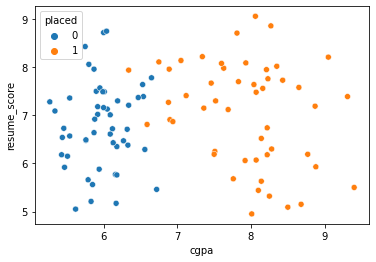

In [47]:
sns.scatterplot(x=df['cgpa'],y=df['resume_score'],hue=df['placed'])

In [51]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [2]:
from sklearn.linear_model import Perceptron
p = Perceptron()

In [53]:
p.fit(X,y)

Perceptron()

In [54]:
p.coef_

array([[ 40.26, -36.  ]])

In [42]:
p.intercept_

array([-25.])

In [38]:
from mlxtend.plotting import plot_decision_regions

<AxesSubplot:>

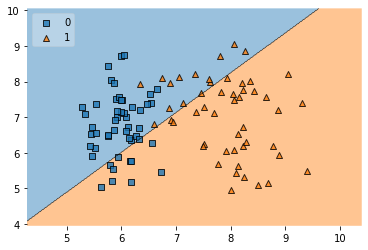

In [45]:
plot_decision_regions(X.values, y.values, clf=p, legend=2)

Perceptron Accuracy: 100.00%


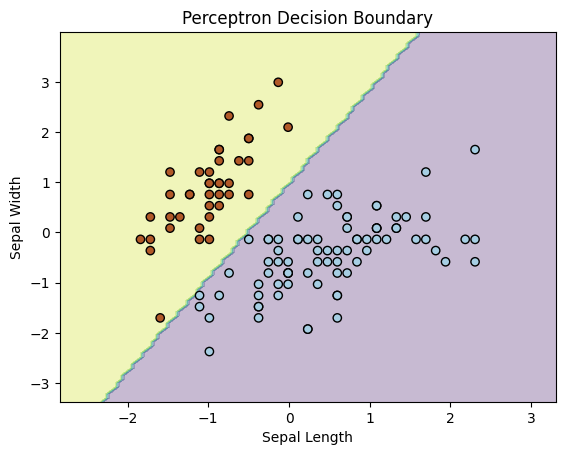

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X = iris.data[:, [0, 1]]  # Selecting two features for visualization (sepal length & sepal width)
y = (iris.target == 0).astype(int)  # Binary classification: Setosa (1) vs. Not Setosa (0)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for Perceptron)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the Perceptron model
perceptron = Perceptron(max_iter=1000, eta0=0.01, random_state=42)
perceptron.fit(X_train, y_train)

# Make predictions
y_pred = perceptron.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Perceptron Accuracy: {accuracy * 100:.2f}%")

# Visualize decision boundary
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap=plt.cm.Paired)
    plt.xlabel("Sepal Length")
    plt.ylabel("Sepal Width")
    plt.title("Perceptron Decision Boundary")
    plt.show()
plot_decision_boundary(X_train, y_train, perceptron)
